In [136]:
coil_params = "Coil Parameters:\nI = 1e6 A \nCoil diameter = 1.0 (m)\n Coil Offset = 1.0m"

In [140]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def plot_b_along_axis(h5_path, L):
    with h5py.File(h5_path, 'r') as f:
        Bx = f['data/1/meshes/B/x'][...]
        By = f['data/1/meshes/B/y'][...]
        Bz = f['data/1/meshes/B/z'][...]

    fig, (ax0, ax1, ax2) = plt.subplots(1, 3, sharey=True, figsize=[10, 5])

    plots = [ax0, ax1, ax2]
    titles = {
        0: '[x, 0, 0]',
        1: '[0, y, 0]',
        2: '[0, 0, z]'
    }
    x_labels = {
        0: 'x (m)',
        1: 'y (m)',
        2: 'z (m)'
    }

    for axis in [0, 1, 2]:
        ax = plots[axis]
        # slice along [x, 0, 0] → y_idx=0, z_idx=0
        Bx_line = Bx[:, 0, 0] if axis == 0 else Bx[0, :, 0] if axis == 1 else Bx[0, 0, :]
        By_line = By[:, 0, 0] if axis == 0 else By[0, :, 0] if axis == 1 else By[0, 0, :]
        Bz_line = Bz[:, 0, 0] if axis == 0 else Bz[0, :, 0] if axis == 1 else Bz[0, 0, :]
        B_mag   = np.sqrt(Bx_line**2 + By_line**2 + Bz_line**2)
        x = np.linspace(0, L, Bx.shape[0])
        ax.plot(x, B_mag)
        ax.grid(True)
        ax.set_xlabel(x_labels[axis]) 
        ax.set_title(titles[axis])
        #ax.set_title(titles[axis])

    fig.suptitle('B-field Magnitude Along [x, y, z]')
    plots[0].set_ylabel("|B| (T)")
    plt.annotate(text = coil_params, xy=[0.01, 0.9], bbox=dict(boxstyle="round", fc="0.8"), xycoords='figure fraction')
    plt.show()

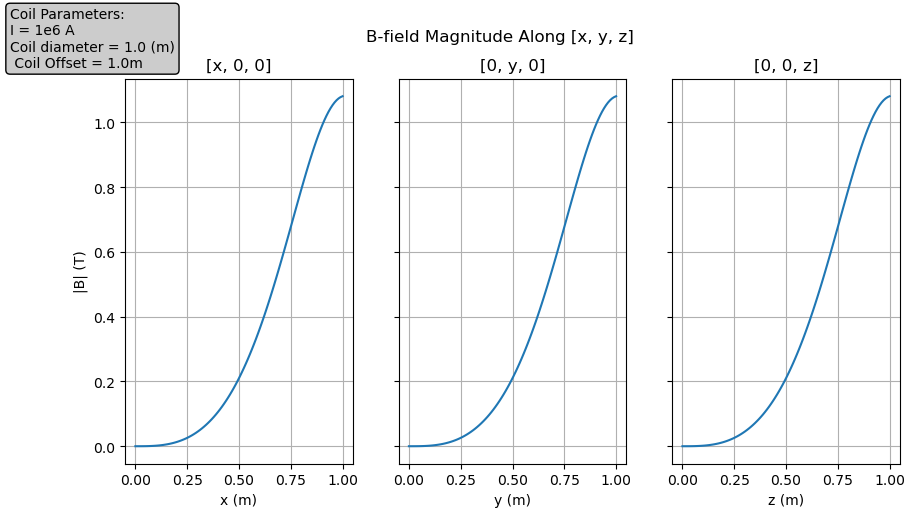

In [141]:
h5_path = '/Users/hehe/Documents/plasma_research/warpx/WarpX_Polywell/output/bext/B_ext_I-1000000.0A_D-1.0m_Off-1.0m_L-1.0m_N-208_sym-octant.h5'
L = 1.0

plot_b_along_axis(h5_path, L)

In [158]:
def plot_b_streamplots(h5_path, L):
    with h5py.File(h5_path, 'r') as f:
        Bx = f['data/1/meshes/B/x'][...]
        By = f['data/1/meshes/B/y'][...]
        Bz = f['data/1/meshes/B/z'][...]

    B_mag = np.sqrt(Bx**2 + By**2 + Bz**2)

    fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)

    N = Bx.shape[0]
    x = np.linspace(0, L, N)
    y = np.linspace(0, L, N)
    z = np.linspace(0, L, N)

    ind = 0

    # XZ @ y = 0
    Bx_slice_xz_y0 = Bx[:, ind, :].T
    Bz_slice_xz_y0 = Bz[:, ind, :].T
    B_mag_slice_xz_y0 = np.log(B_mag[:, ind, :]).T

    # XY @ z = 0
    Bx_slice_xy_z0 = Bx[:, :, ind].T
    By_slice_xy_z0 = By[:, :, ind].T
    B_mag_slice_xy_z0 = np.log(B_mag[:, :, ind]).T

    # YZ @ x = 0
    By_slice_yz_x0 = By[ind, :, :].T
    Bz_slice_yz_x0 = Bz[ind, :, :].T
    B_mag_slice_yz_x0 = np.log(B_mag[ind, :, :]).T

    from matplotlib import colors 
    datasets = [B_mag_slice_xz_y0, B_mag_slice_xy_z0, B_mag_slice_yz_x0]
    norm = colors.Normalize(vmin=1e-2*np.max(datasets), vmax=np.max(datasets))

    levels = 50
    density = 1.0

    cf = ax0.contourf(x, z, B_mag_slice_xz_y0, levels=levels, cmap='viridis', norm=norm)
    ax0.streamplot(x, z, Bx_slice_xz_y0, Bz_slice_xz_y0, color='white', linewidth=0.8, density=density)
    ax0.set_title('XZ slice @ y = 0')
    ax0.set_xlabel('x (m)')
    ax0.set_ylabel('z (m)')

    ax1.contourf(x, y, B_mag_slice_xy_z0, levels=levels, cmap='viridis', norm=norm)
    ax1.streamplot(x, y, Bx_slice_xy_z0, By_slice_xy_z0, color='white', linewidth=0.8, density=density)
    ax1.set_title('XY slice @ z = 0')
    ax1.set_xlabel('x (m)')
    ax1.set_ylabel('y (m)')

    ax2.contourf(x, y, B_mag_slice_yz_x0, levels=levels, cmap='viridis', norm=norm)
    ax2.streamplot(x, y, By_slice_yz_x0, Bz_slice_yz_x0, color='white', linewidth=0.8, density=density)
    ax2.set_title('YZ slice @ x = 0')
    ax2.set_xlabel('y (m)')
    ax2.set_ylabel('z (m)')

    fig.suptitle('B-field on |B|')
    plt.annotate(text = coil_params, xy=[0.01, 0.9], bbox=dict(boxstyle="round", fc="0.8"))
    plt.colorbar(cf, ax=ax2, label='log(|B|) T', pad=0.1)

def plot_b_streamplot_xz(h5_path, L):
    with h5py.File(h5_path, 'r') as f:
        Bx = f['data/1/meshes/B/x'][...]
        By = f['data/1/meshes/B/y'][...]
        Bz = f['data/1/meshes/B/z'][...]

    N = Bx.shape[0]
    x = np.linspace(0, L, N)
    z = np.linspace(0, L, N)

    B_mag = np.sqrt(Bx**2 + By**2 + Bz**2)

    ind = 0  # y=0 plane
    Bx_slice = Bx[:, ind, :].T
    Bz_slice = Bz[:, ind, :].T
    B_mag_slice = np.log(B_mag[:, ind, :]).T

    fig, ax = plt.subplots()
    cf = ax.contourf(x, z, B_mag_slice, levels=50, cmap='viridis')
    ax.streamplot(x, z, Bx_slice, Bz_slice, color='white', linewidth=0.8, density=1.5)
    plt.colorbar(cf, ax=ax, label='log|B| (T)')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('z (m)')
    ax.set_title('B-field streamplot — xz plane (y=0)')
    plt.tight_layout()
    plt.show()

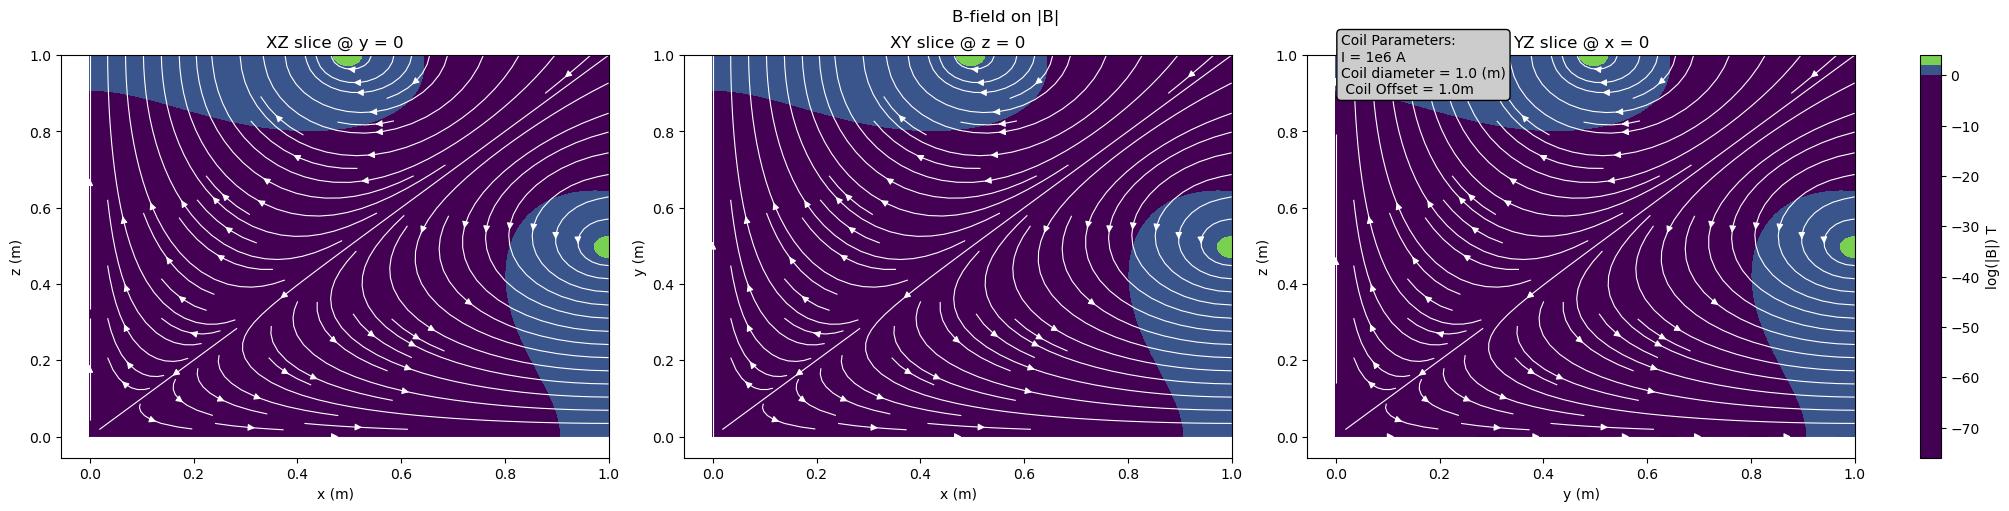

In [159]:
plot_b_streamplots(h5_path, L)

In [148]:
from scipy.interpolate import RegularGridInterpolator

def plot_b_along_diagonal(h5_path, L):
    with h5py.File(h5_path, 'r') as f:
        Bx = f['data/1/meshes/B/x'][...]
        By = f['data/1/meshes/B/y'][...]
        Bz = f['data/1/meshes/B/z'][...]

    N = Bx.shape[0]
    x = np.linspace(0, L, N)

    # grabs points at [0, 0, 0], [0.]
    # interpolators for each component
    interp_Bx = RegularGridInterpolator((x, x, x), Bx)
    interp_By = RegularGridInterpolator((x, x, x), By)
    interp_Bz = RegularGridInterpolator((x, x, x), Bz)

    # sample points along [1,1,1] from origin to corner (L,L,L)
    t = np.linspace(0, L, 300)
    points = np.column_stack([t, t, t])  # shape (300, 3)

    B_mag = np.sqrt(
        interp_Bx(points)**2 +
        interp_By(points)**2 +
        interp_Bz(points)**2
    )

    # distance along diagonal
    d = t * np.sqrt(3)

    plt.figure()
    plt.plot(d, B_mag)
    plt.xlabel('distance along [1,1,1] (m)')
    plt.ylabel('|B| (T)')
    plt.title('B-field magnitude along [1,1,1] corner diagonal')
    plt.grid(True)
    plt.tight_layout()
    plt.annotate('[x, y, z] = [L√3]³', xy=[d[-1], B_mag[-1]], xytext=[d[-1], B_mag[-1] + 0.05], bbox=dict(boxstyle="round", fc="0.8"), arrowprops=dict(arrowstyle="->"))
    plt.annotate(text = coil_params, xy=[0.9, 0.9], bbox=dict(boxstyle="round", fc="0.8"), xycoords='figure fraction')
    plt.show()

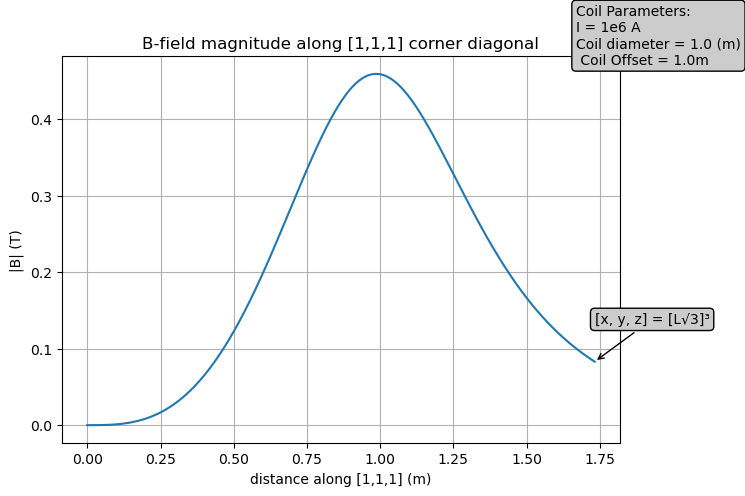

In [149]:
plot_b_along_diagonal(h5_path, L)

In [180]:
def plot_b_streamplot_diagonal(h5_path, L):
    with h5py.File(h5_path, 'r') as f:
        Bx = f['data/1/meshes/B/x'][...]
        By = f['data/1/meshes/B/y'][...]
        Bz = f['data/1/meshes/B/z'][...]

    N = Bx.shape[0]
    x = np.linspace(0, L, N)
    z = np.linspace(0, L, N)

    interp_Bx = RegularGridInterpolator((x, x, x), Bx)
    interp_By = RegularGridInterpolator((x, x, x), By)
    interp_Bz = RegularGridInterpolator((x, x, x), Bz)

    # 2D grid on x=y plane
    # s parameterizes [1,1,0] direction, z is vertical
    s = np.linspace(0, L, N)  # s ∈ [0, L], maps to x=y=s
    s_grid, z_grid = np.meshgrid(s, z)

    # sample points: (x=s, y=s, z)
    points = np.column_stack([s_grid.ravel(), s_grid.ravel(), z_grid.ravel()])

    Bx_p = interp_Bx(points).reshape(N, N)
    By_p = interp_By(points).reshape(N, N)
    Bz_p = interp_Bz(points).reshape(N, N)

    # project onto plane basis vectors
    Bs = (Bx_p + By_p) / np.sqrt(2)   # along [1,1,0]
    B_mag = np.sqrt(Bx_p**2 + By_p**2 + Bz_p**2)

    fig, ax = plt.subplots()
    cf = ax.contourf(s, z, np.log(B_mag), levels=50, cmap='viridis')
    ax.streamplot(s, z, Bs, Bz_p, color='white', linewidth=0.8, density=1.5)
    plt.colorbar(cf, ax=ax, label='log|B| (T)')
    ax.set_xlabel('s = x = y (m)')
    ax.set_ylabel('z (m)')
    ax.set_title('B-field streamplot — diagonal plane (x=y)')
    ax.plot(s, s, 'b--', linewidth=1.0, label='[1,1,1] diagonal')
    ax.legend()
    ax.annotate('corner cusp', xy=(L, L), xytext=(L*0.7, L*0.85),
                color='red', arrowprops=dict(arrowstyle='->', color='white'))
    ax.annotate('z-face cusp', xy=(0, L), xytext=(0.05*L, L*0.82),
                color='red', arrowprops=dict(arrowstyle='->', color='white'))
    ax.annotate('interior', xy=(0, 0), xytext=(0.05*L, 0.15*L),
                color='red', arrowprops=dict(arrowstyle='->', color='white'))
    plt.tight_layout()
    plt.show()


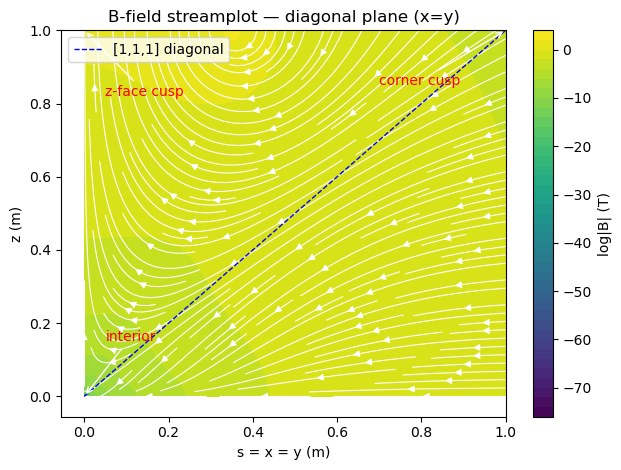

In [181]:
plot_b_streamplot_diagonal(h5_path, L)